# Notebook 27 — D=7 Barlow-Twins Embedding: Trajectories + 2-D Views (standalone)
**Project:** ENSO-BSISO SSL — MJO extension  
**Author:** Jiayi (jh9141@nyu.edu)

Lightweight, **no-retrain** viewer for the **D=7** Barlow-Twins embedding from nb26. Loads the saved
`embeddings_z7.npy` (no model / torch / GPU needed) and reproduces, for D=7:
- PCA + t-SNE 2-D scatter colored by RMM phase / ENSO / amplitude (nb26 Cell 9), and
- **event trajectories** — consecutive days of the strongest MJO events as connected paths through PCA-2D (nb26 Cell 10).

**Reuse vs retrain:** *reuse* — the D=7 embedding was already saved by the earlier nb26 D=7 run to `MJO/barlow/embeddings_z7.npy`. (The later D=3 runs wrote to `MJO/barlow/D3/`, so the base file is still D=7.) Only re-run nb26 with `PROJ_DIM=7` if that file is missing or not 7-dimensional (Cell 1 checks).

**Inputs:** `MJO/barlow/embeddings_z7.npy` (N, 7); `MJO/data/processed/labels_aligned_mjo_bp20_90.csv`.  
**Outputs:** `MJO/barlow/D7_embedding_2d.png`, `MJO/barlow/D7_trajectories_pca.png`.

---

## Cell 0 — Train a fresh D=7 Barlow Twins (run once, with C(τ) recording)

A **self-contained D=7 training** (same pipeline as nb26, fixed to `PROJ_DIM=7`, τ-graded loss, warm-start from the nb21 encoder). It records the 7×7 `C(τ)` every epoch and writes `encoder_bt.pth`, `projector_bt.pth`, `embeddings_z7.npy`, and `bt_corr_history.npz` to **`MJO/barlow/D7/`**. **Auto-skips** if those already exist (set `RETRAIN_D7=True` to force). After this one run, every viewer cell below (trajectories, C-evolution) reads the **D=7** artifacts from disk — no further training. Needs a **T4 GPU** (≈ a few minutes).

In [1]:
# ===== TRAIN a fresh D=7 Barlow Twins (with C(tau) recording) — run ONCE =====
# Mirrors nb26 fixed to PROJ_DIM=7; writes encoder_bt / projector_bt / embeddings_z7 /
# bt_corr_history.npz to barlow/D7/. Skips automatically if those already exist.
import os, time, copy
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torch.utils.data import Dataset, DataLoader

RETRAIN_D7 = False                  # set True to retrain even if artifacts exist
if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive; drive.mount('/content/drive')
MJO_DIR = '/content/drive/MyDrive/BSISO_SSL_Project/MJO'
PROCESSED_DIR = f'{MJO_DIR}/data/processed'; NSV_CKPT_DIR = f'{MJO_DIR}/nsv/checkpoints_lag10'
OUT_DIR = f'{MJO_DIR}/barlow/D7'; os.makedirs(OUT_DIR, exist_ok=True)

_have = os.path.exists(f'{OUT_DIR}/bt_corr_history.npz') and os.path.exists(f'{OUT_DIR}/embeddings_z7.npy')
if _have and not RETRAIN_D7:
    print(f'D=7 artifacts already in {OUT_DIR} -> skip training (set RETRAIN_D7=True to redo).')
else:
    TAUS = [1, 2, 3, 4, 5]; PROJ_DIM = 7; LATENT_DIM = 64; LAMBDA_OFF_BASE = 5e-3
    BATCH_SIZE = 256; EPOCHS = 100; LR = 1e-3; WEIGHT_DECAY = 1e-4; SEED = 42; VAL_STRIDE = 5
    LAMBDA_TAU_MAX, LAMBDA_TAU_MIN, SCHED_MODE = 1.0, 0.05, 'exp'
    def sched(t):
        f = (t - min(TAUS)) / (max(TAUS) - min(TAUS))
        return LAMBDA_TAU_MAX * (LAMBDA_TAU_MIN / LAMBDA_TAU_MAX) ** f if SCHED_MODE == 'exp' \
            else LAMBDA_TAU_MAX + (LAMBDA_TAU_MIN - LAMBDA_TAU_MAX) * f
    torch.manual_seed(SEED); np.random.seed(SEED)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Device:', device, ' lambda(tau):', {t: round(sched(t), 3) for t in TAUS})

    X = np.load(f'{PROCESSED_DIR}/X_MJO_bp20_90.npy')
    labels = pd.read_csv(f'{PROCESSED_DIR}/labels_aligned_mjo_bp20_90.csv', parse_dates=['date'])
    labels['date'] = labels['date'].dt.normalize()
    order = np.argsort(labels['date'].values)
    if not np.array_equal(order, np.arange(len(labels))):
        X = X[order]; labels = labels.iloc[order].reset_index(drop=True)
    X = X.reshape(X.shape[0], 3, 180).astype(np.float32); N = len(X)
    dates_all = pd.DatetimeIndex(labels['date'].values); years = dates_all.year.values
    val_years = sorted(np.unique(years))[::VAL_STRIDE]; is_val = np.isin(years, val_years)
    Xt = torch.from_numpy(X)

    class PairIdx(Dataset):
        def __init__(s, Xt, it, it1): s.Xt = Xt; s.it = it; s.it1 = it1
        def __len__(s): return len(s.it)
        def __getitem__(s, k): return s.Xt[s.it[k]], s.Xt[s.it1[k]]
    def build_pairs(tau):
        delta = (dates_all[tau:] - dates_all[:-tau]).days
        it = np.where((delta == tau) & (is_val[:-tau] == is_val[tau:]))[0]
        return it, it + tau
    train_loaders, val_loaders = {}, {}
    for tau in TAUS:
        it, it1 = build_pairs(tau); av = is_val[it]
        train_loaders[tau] = DataLoader(PairIdx(Xt, it[~av], it1[~av]), batch_size=BATCH_SIZE, shuffle=True,
                                        num_workers=2, pin_memory=(device.type == 'cuda'), drop_last=True)
        val_loaders[tau] = DataLoader(PairIdx(Xt, it[av], it1[av]), batch_size=BATCH_SIZE, shuffle=False,
                                      num_workers=2, pin_memory=(device.type == 'cuda'))

    class EncoderMJO(nn.Module):
        def __init__(s, latent_dim=64):
            super().__init__()
            s.conv1 = nn.Conv1d(3, 16, 4, 2, 1, bias=False); s.bn1 = nn.BatchNorm1d(16)
            s.conv2 = nn.Conv1d(16, 32, 3, 1, 1, bias=False); s.bn2 = nn.BatchNorm1d(32)
            s.conv3 = nn.Conv1d(32, 32, 4, 2, 1, bias=False); s.bn3 = nn.BatchNorm1d(32)
            s.conv4 = nn.Conv1d(32, 64, 3, 1, 1, bias=False); s.bn4 = nn.BatchNorm1d(64)
            s.conv5 = nn.Conv1d(64, 128, 4, 2, 1, bias=False); s.bn5 = nn.BatchNorm1d(128)
            s.gap = nn.AdaptiveAvgPool1d(1); s.fc = nn.Linear(128, latent_dim)
        def forward(s, x):
            x = F.relu(s.bn1(s.conv1(x))); x = F.relu(s.bn2(s.conv2(x))); x = F.relu(s.bn3(s.conv3(x)))
            x = F.relu(s.bn4(s.conv4(x))); x = F.relu(s.bn5(s.conv5(x))); return s.fc(s.gap(x).flatten(1))
    class Projector(nn.Module):
        def __init__(s, i=64, o=7):
            super().__init__()
            s.net = nn.Sequential(nn.Linear(i, 128), nn.BatchNorm1d(128), nn.ReLU(True),
                                  nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(True), nn.Linear(64, o))
        def forward(s, x): return s.net(x)
    encoder = EncoderMJO(LATENT_DIM).to(device); projector = Projector(LATENT_DIM, PROJ_DIM).to(device)
    ck = f'{NSV_CKPT_DIR}/encoder_stage1_best.pth'
    if os.path.exists(ck): encoder.load_state_dict(torch.load(ck, map_location=device)); print('warm-started encoder from nb21')

    def cross_corr(zA, zB, eps=1e-5):
        zA = (zA - zA.mean(0)) / (zA.std(0) + eps); zB = (zB - zB.mean(0)) / (zB.std(0) + eps)
        return (zA.T @ zB) / zA.size(0)
    def bt_loss(C, li, lo):
        on = torch.diagonal(C).add(-1).pow(2).sum(); off = (C - torch.diag(torch.diagonal(C))).pow(2).sum()
        return li * on + lo * off

    opt = optim.Adam(list(encoder.parameters()) + list(projector.parameters()), lr=LR, weight_decay=WEIGHT_DECAY)
    schd = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=LR * 0.01)
    eval_batches = {t: tuple(x.to(device) for x in next(iter(val_loaders[t]))) for t in TAUS}
    C_hist = {t: [] for t in TAUS}
    def record_C():
        encoder.eval(); projector.eval()
        with torch.no_grad():
            for t in TAUS:
                xa, xb = eval_batches[t]
                C_hist[t].append(cross_corr(projector(encoder(xa)), projector(encoder(xb))).cpu().numpy())
        encoder.train(); projector.train()
    spe = min(len(train_loaders[t]) for t in TAUS); best = float('inf'); best_state = None; t0 = time.time()
    record_C()
    for ep in range(EPOCHS):
        encoder.train(); projector.train(); iters = {t: iter(train_loaders[t]) for t in TAUS}; el = 0.0
        for _ in range(spe):
            opt.zero_grad(); tot = 0.0
            for tau in TAUS:
                xa, xb = next(iters[tau]); xa = xa.to(device); xb = xb.to(device)
                C = cross_corr(projector(encoder(xa)), projector(encoder(xb)))
                tot = tot + bt_loss(C, sched(tau), LAMBDA_OFF_BASE * sched(tau))
            tot.backward(); opt.step(); el += tot.item()
        schd.step(); record_C()
        if el / spe < best: best = el / spe; best_state = (copy.deepcopy(encoder.state_dict()), copy.deepcopy(projector.state_dict()))
        if (ep + 1) % 10 == 0 or ep < 3: print(f'ep {ep+1:3d}/{EPOCHS}  loss={el/spe:.4f}')
    if best_state: encoder.load_state_dict(best_state[0]); projector.load_state_dict(best_state[1])
    torch.save(encoder.state_dict(), f'{OUT_DIR}/encoder_bt.pth')
    torch.save(projector.state_dict(), f'{OUT_DIR}/projector_bt.pth')
    np.savez(f'{OUT_DIR}/bt_corr_history.npz', taus=np.array(TAUS),
             lambdas=np.array([sched(t) for t in TAUS], dtype=float), proj_dim=PROJ_DIM,
             **{f'C_tau{t}': np.array(C_hist[t]) for t in TAUS})
    encoder.eval(); projector.eval(); z7out = np.zeros((N, PROJ_DIM), np.float32)
    with torch.no_grad():
        for s0 in range(0, N, 512):
            z7out[s0:s0+512] = projector(encoder(Xt[s0:s0+512].to(device))).cpu().numpy()
    np.save(f'{OUT_DIR}/embeddings_z7.npy', z7out)
    print(f'Done in {(time.time()-t0)/60:.1f} min -> saved encoder_bt, projector_bt, embeddings_z7 (D=7), '
          f'bt_corr_history.npz (7x7) in {OUT_DIR}')

Mounted at /content/drive
Device: cuda  lambda(tau): {1: 1.0, 2: 0.473, 3: 0.224, 4: 0.106, 5: 0.05}
warm-started encoder from nb21
ep   1/100  loss=0.1600
ep   2/100  loss=0.1080
ep   3/100  loss=0.0908
ep  10/100  loss=0.0291
ep  20/100  loss=0.0122
ep  30/100  loss=0.0059
ep  40/100  loss=0.0037
ep  50/100  loss=0.0027
ep  60/100  loss=0.0020
ep  70/100  loss=0.0020
ep  80/100  loss=0.0023
ep  90/100  loss=0.0013
ep 100/100  loss=0.0012
Done in 5.8 min -> saved encoder_bt, projector_bt, embeddings_z7 (D=7), bt_corr_history.npz (7x7) in /content/drive/MyDrive/BSISO_SSL_Project/MJO/barlow/D7


## Cell 1 — Load the saved D=7 embedding + labels (aligned)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR   = '/content/drive/MyDrive/BSISO_SSL_Project'
MJO_DIR       = f'{PROJECT_DIR}/MJO'
PROCESSED_DIR = f'{MJO_DIR}/data/processed'
OUT_DIR       = f'{MJO_DIR}/barlow'

# saved D=7 embedding (base barlow/ folder; D=3 runs are under barlow/D3/)
EMB_CANDIDATES = [f'{OUT_DIR}/D7/embeddings_z7.npy', f'{OUT_DIR}/embeddings_z7.npy']
emb_path = next((p for p in EMB_CANDIDATES if os.path.exists(p)), None)
assert emb_path is not None, ('No saved embedding found. Re-run nb26 with PROJ_DIM=7 to create '
                              'MJO/barlow/embeddings_z7.npy.')
z7 = np.load(emb_path)
print(f'Loaded {emb_path}  shape={z7.shape}')
if z7.shape[1] != 7:
    print(f'WARNING: embedding dim is {z7.shape[1]}, not 7. This file is from a non-D=7 run; '
          're-run nb26 with PROJ_DIM=7 if you want the D=7 trajectories.')

# labels, sorted by date to match the order nb26 saved the embedding in (nb26 Cell 2 sorts)
labels = pd.read_csv(f'{PROCESSED_DIR}/labels_aligned_mjo_bp20_90.csv', parse_dates=['date'])
labels['date'] = labels['date'].dt.normalize()
labels = labels.iloc[np.argsort(labels['date'].values)].reset_index(drop=True)
assert len(labels) == len(z7), f'labels {len(labels)} != embedding {len(z7)} (different preprocessing run?)'

N         = len(z7)
dates_all = pd.DatetimeIndex(labels['date'].values)
phase_all = labels['phase'].values.astype(int)
amp_all   = labels['amplitude'].values
enso_all  = labels['enso_category'].values
weak_all  = labels['weak_mjo'].values.astype(bool)
active    = (~weak_all) & (amp_all >= 1.0)
print(f'N={N}  active(amp>=1)={int(active.sum())}  ({dates_all.min().date()}..{dates_all.max().date()})')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded /content/drive/MyDrive/BSISO_SSL_Project/MJO/barlow/D7/embeddings_z7.npy  shape=(16256, 7)
N=16256  active(amp>=1)=10042  (1979-04-01..2023-10-02)


## Cell 2 — PCA + t-SNE 2-D scatter (by phase / ENSO / amplitude)

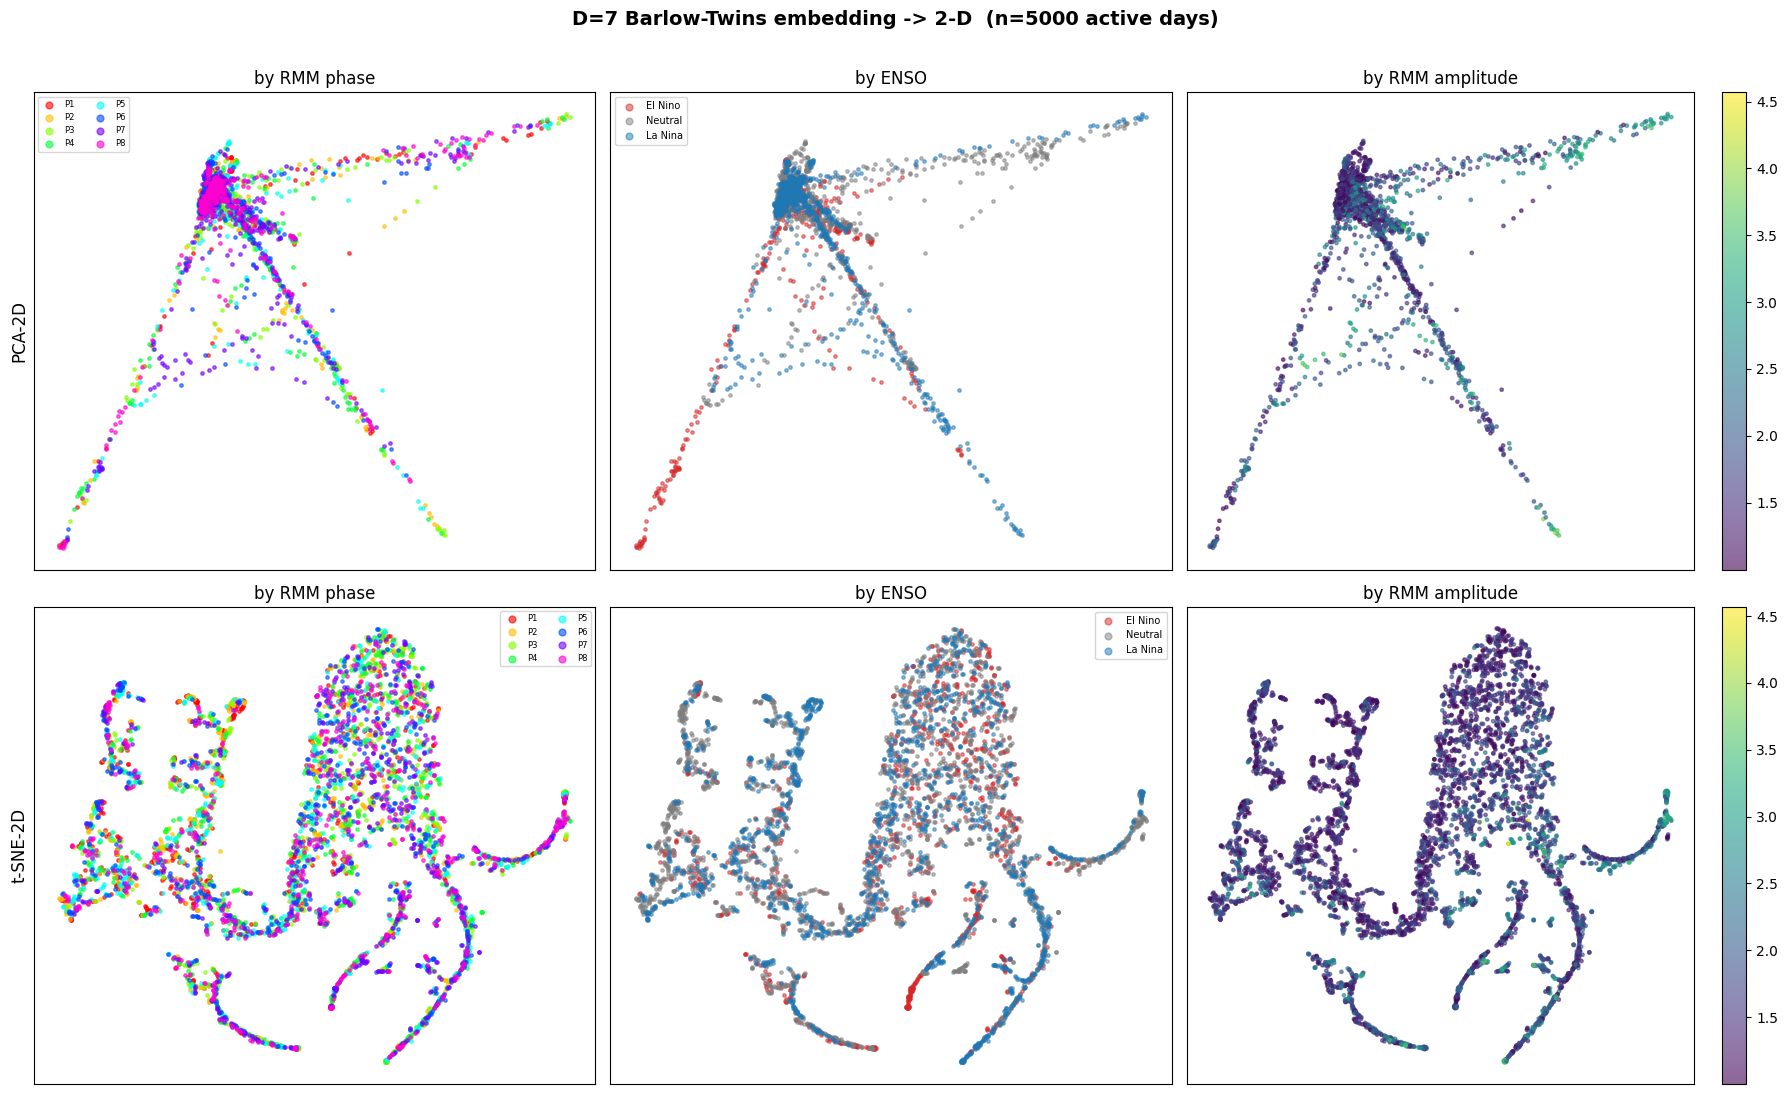

Saved /content/drive/MyDrive/BSISO_SSL_Project/MJO/barlow/D7_embedding_2d.png


In [3]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

idxa = np.where(active)[0]
rng  = np.random.default_rng(0)
sub  = rng.choice(idxa, size=min(5000, len(idxa)), replace=False)
Zs   = z7[sub]
ph   = phase_all[sub]; en = enso_all[sub]; am = amp_all[sub]

pca2  = PCA(2).fit_transform(Zs - Zs.mean(0))
tsne2 = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto',
             random_state=0).fit_transform(Zs)

phase_colors = plt.cm.hsv(np.linspace(0, 1, 9))   # cyclic: a phase LOOP would order around the wheel
enso_pal = {'El Nino': '#d62728', 'Neutral': '#7f7f7f', 'La Nina': '#1f77b4'}

def scatter_by(ax, XY, kind):
    if kind == 'phase':
        for p in range(1, 9):
            m = ph == p
            ax.scatter(XY[m, 0], XY[m, 1], s=6, alpha=0.6, color=phase_colors[p-1], label=f'P{p}')
        ax.set_title('by RMM phase'); ax.legend(fontsize=6, ncol=2, markerscale=2)
    elif kind == 'enso':
        for c in ['El Nino', 'Neutral', 'La Nina']:
            m = en == c
            ax.scatter(XY[m, 0], XY[m, 1], s=6, alpha=0.5, color=enso_pal[c], label=c)
        ax.set_title('by ENSO'); ax.legend(fontsize=7, markerscale=2)
    else:
        sc = ax.scatter(XY[:, 0], XY[:, 1], s=6, alpha=0.6, c=am, cmap='viridis')
        ax.set_title('by RMM amplitude'); plt.colorbar(sc, ax=ax, fraction=0.046)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for j, kind in enumerate(['phase', 'enso', 'amplitude']):
    scatter_by(axes[0, j], pca2,  kind)
    scatter_by(axes[1, j], tsne2, kind)
axes[0, 0].set_ylabel('PCA-2D', fontsize=12)
axes[1, 0].set_ylabel('t-SNE-2D', fontsize=12)
plt.suptitle(f'D=7 Barlow-Twins embedding -> 2-D  (n={len(sub)} active days)',
             fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.98])
p = f'{OUT_DIR}/D7_embedding_2d.png'
plt.savefig(p, dpi=130, bbox_inches='tight'); plt.show(); print('Saved', p)

## Cell 3 — Event Trajectories (connected paths in PCA-2D)

Connect consecutive days of the 3 strongest MJO events as paths through the D=7 embedding (PCA-2D), over a faint background of all active days. PCA only (linear → continuity is faithful); t-SNE is avoided for paths (non-metric → misleading lines). ★ start, ■ end, markers colored by RMM phase. A clean MJO event would trace a phase-ordered loop.

Plotting 3 strongest MJO events in SEPARATE panels (>=25 consecutive active days).


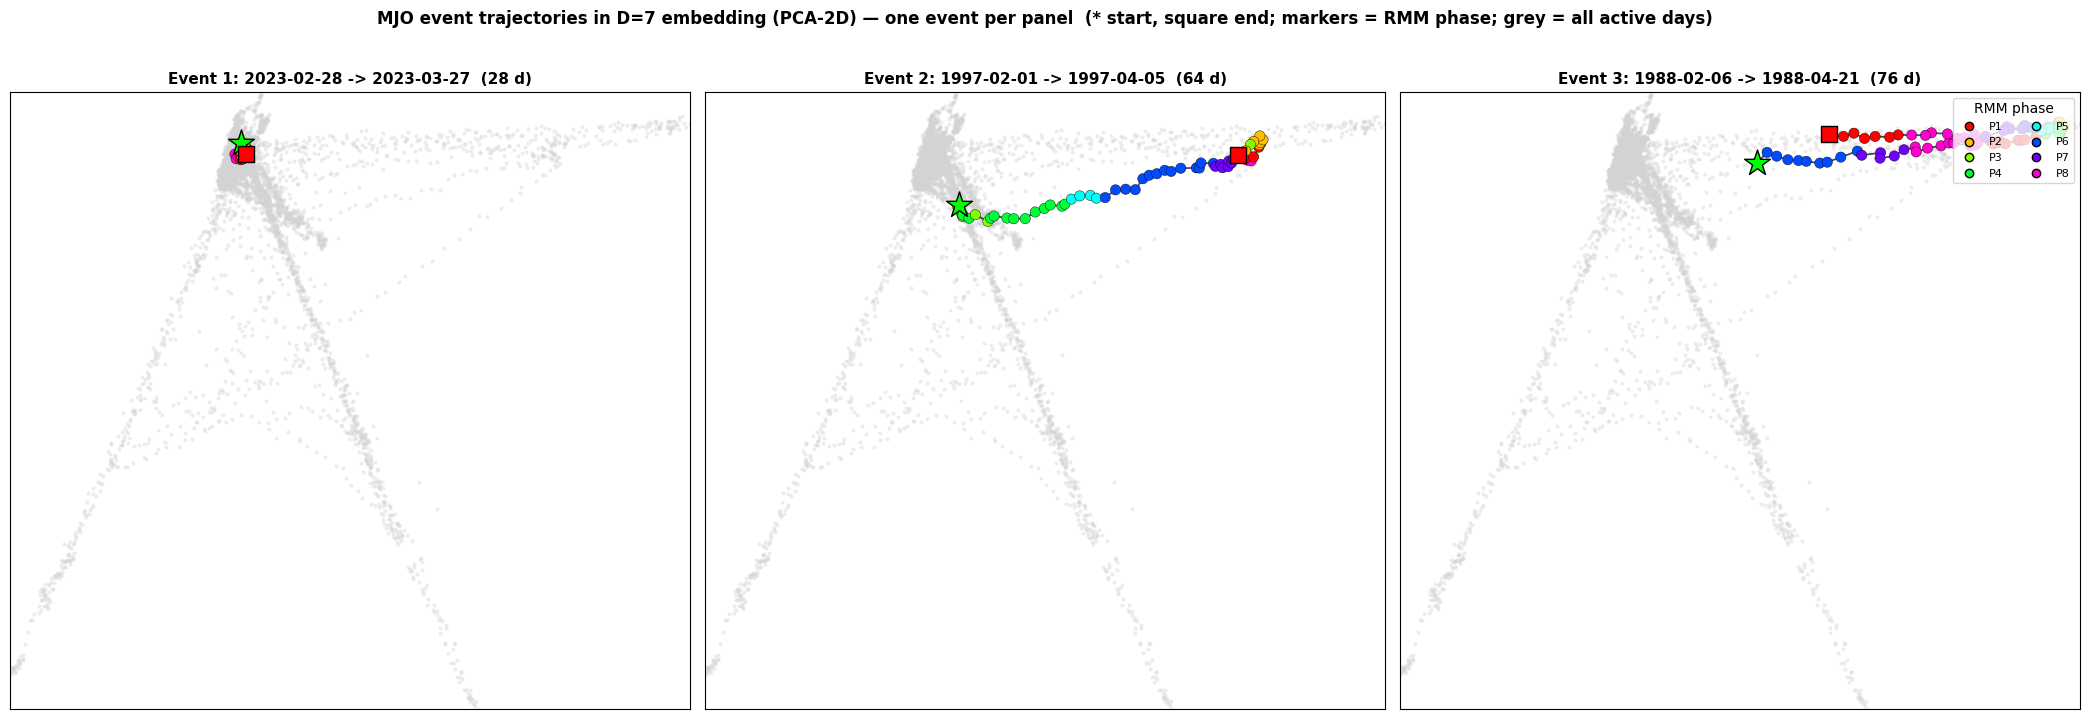

Saved /content/drive/MyDrive/BSISO_SSL_Project/MJO/barlow/D7_trajectories_pca.png
A clean MJO event would trace a LOOP with phases 1->8 ordered around it.


In [4]:
from sklearn.decomposition import PCA

mu = z7[idxa].mean(0)
P2 = PCA(2).fit(z7[idxa] - mu)
bg = P2.transform(z7[idxa] - mu)

# contiguous active runs (consecutive calendar days, amplitude >= 1) of length >= 25
runs = []; i = 0
while i < N:
    if active[i]:
        j = i
        while j + 1 < N and active[j + 1] and int((dates_all[j + 1] - dates_all[j]).days) == 1:
            j += 1
        if j - i + 1 >= 25:
            runs.append((i, j))
        i = j + 1
    else:
        i += 1
runs = sorted(runs, key=lambda r: amp_all[r[0]:r[1] + 1].mean(), reverse=True)[:3]
print(f'Plotting {len(runs)} strongest MJO events in SEPARATE panels (>=25 consecutive active days).')

phase_colors = plt.cm.hsv(np.linspace(0, 1, 9))
# one panel per event so trajectories don't overlap
fig, axes = plt.subplots(1, len(runs), figsize=(7 * len(runs), 7), squeeze=False)
axes = axes[0]
xlim = (bg[:, 0].min(), bg[:, 0].max()); ylim = (bg[:, 1].min(), bg[:, 1].max())
for k, (a, b) in enumerate(runs):
    ax = axes[k]
    ax.scatter(bg[:, 0], bg[:, 1], s=4, c='lightgray', alpha=0.30, zorder=1)   # same background each panel
    seg = P2.transform(z7[a:b + 1] - mu)
    ph  = phase_all[a:b + 1]
    ax.plot(seg[:, 0], seg[:, 1], '-', color='k', lw=1.3, alpha=0.7, zorder=2)
    ax.scatter(seg[:, 0], seg[:, 1], c=[phase_colors[p - 1] for p in ph], s=55,
               edgecolor='k', linewidth=0.3, zorder=3)
    ax.scatter(*seg[0],  marker='*', s=380, c='lime', edgecolor='k', zorder=4)   # start
    ax.scatter(*seg[-1], marker='s', s=130, c='red',  edgecolor='k', zorder=4)   # end
    ax.set_title(f'Event {k+1}: {dates_all[a].date()} -> {dates_all[b].date()}  ({b-a+1} d)',
                 fontsize=11, fontweight='bold')
    ax.set_xlim(xlim); ax.set_ylim(ylim)   # shared axes so panels are comparable
    ax.set_xticks([]); ax.set_yticks([])
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker='o', ls='', mfc=phase_colors[p - 1], mec='k', label=f'P{p}') for p in range(1, 9)]
axes[-1].legend(handles=handles, fontsize=8, ncol=2, title='RMM phase', loc='upper right')
plt.suptitle('MJO event trajectories in D=7 embedding (PCA-2D) — one event per panel  '
             '(* start, square end; markers = RMM phase; grey = all active days)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
p = f'{OUT_DIR}/D7_trajectories_pca.png'
plt.savefig(p, dpi=140, bbox_inches='tight'); plt.show(); print('Saved', p)
print('A clean MJO event would trace a LOOP with phases 1->8 ordered around it.')

## Cell 4 — Event Trajectories in PCA-**3D**

Same 3 strongest MJO events, but PCA reduced to **3 components** and drawn on 3-D axes (one event per 3-D panel). For D=7 the top-3 PCs capture more of the embedding than the 2-D view, so a curved/looping path is easier to see. ★ start, ■ end, markers colored by RMM phase; faint grey = all active days. Saves `D7_trajectories_pca3d.png`.

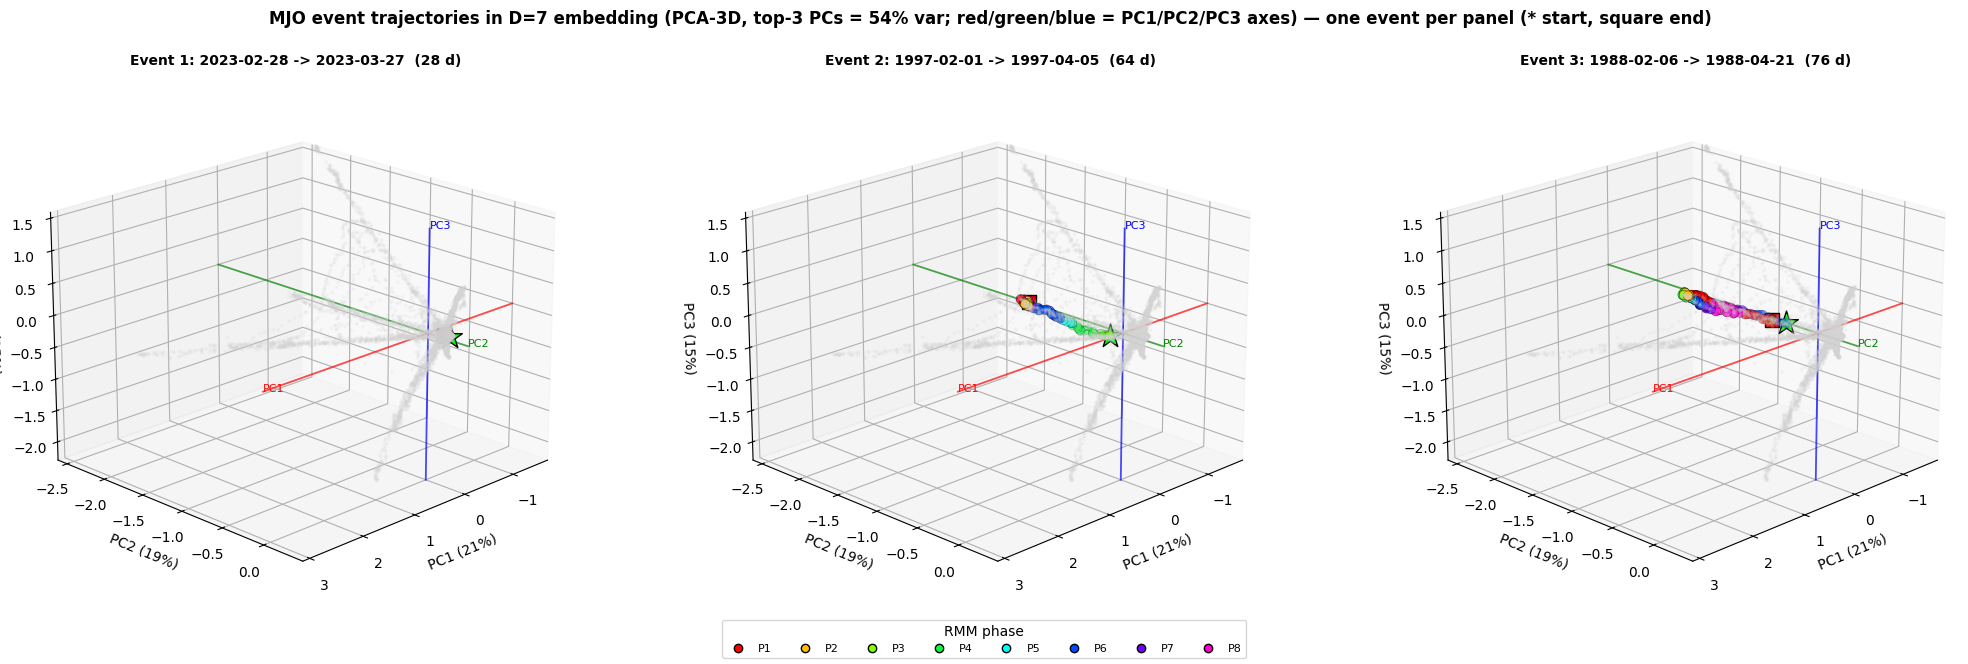

Saved /content/drive/MyDrive/BSISO_SSL_Project/MJO/barlow/D7_trajectories_pca3d.png
Top-3 PC variance: [20.7 18.6 15.2]  (sum 54.4%)


In [5]:
# 3-D PCA trajectories: same events, but PCA to 3 components on 3-D axes (one event per panel).
# For D=7 the top-3 PCs capture more of the embedding than the 2-D projection above.
# PC1/PC2/PC3 axes (red/green/blue) are drawn through the origin to read each path's orientation.
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401 (enables projection='3d')

mu3 = z7[idxa].mean(0)
P3  = PCA(3).fit(z7[idxa] - mu3)
bg3 = P3.transform(z7[idxa] - mu3)
vr  = P3.explained_variance_ratio_ * 100

# reuse the same 3 strongest contiguous active events
runs = []; i = 0
while i < N:
    if active[i]:
        j = i
        while j + 1 < N and active[j + 1] and int((dates_all[j + 1] - dates_all[j]).days) == 1:
            j += 1
        if j - i + 1 >= 25:
            runs.append((i, j))
        i = j + 1
    else:
        i += 1
runs = sorted(runs, key=lambda r: amp_all[r[0]:r[1] + 1].mean(), reverse=True)[:3]

phase_colors = plt.cm.hsv(np.linspace(0, 1, 9))
fig = plt.figure(figsize=(7 * len(runs), 6.5))
lims = [(bg3[:, d].min(), bg3[:, d].max()) for d in range(3)]
for k, (a, b) in enumerate(runs):
    ax = fig.add_subplot(1, len(runs), k + 1, projection='3d')
    ax.scatter(bg3[:, 0], bg3[:, 1], bg3[:, 2], s=3, c='lightgray', alpha=0.12, zorder=1)
    # PC axes through the origin (red=PC1, green=PC2, blue=PC3)
    ax.plot(lims[0], [0, 0], [0, 0], color='red',   lw=1.3, alpha=0.7)
    ax.plot([0, 0], lims[1], [0, 0], color='green', lw=1.3, alpha=0.7)
    ax.plot([0, 0], [0, 0], lims[2], color='blue',  lw=1.3, alpha=0.7)
    ax.text(lims[0][1], 0, 0, 'PC1', color='red', fontsize=8)
    ax.text(0, lims[1][1], 0, 'PC2', color='green', fontsize=8)
    ax.text(0, 0, lims[2][1], 'PC3', color='blue', fontsize=8)
    seg = P3.transform(z7[a:b + 1] - mu3)
    ph  = phase_all[a:b + 1]
    ax.plot(seg[:, 0], seg[:, 1], seg[:, 2], '-', color='k', lw=1.3, alpha=0.7, zorder=2)
    ax.scatter(seg[:, 0], seg[:, 1], seg[:, 2], c=[phase_colors[p - 1] for p in ph],
               s=45, edgecolor='k', linewidth=0.3, zorder=3)
    ax.scatter(*seg[0],  marker='*', s=320, c='lime', edgecolor='k', zorder=4)   # start
    ax.scatter(*seg[-1], marker='s', s=110, c='red',  edgecolor='k', zorder=4)   # end
    ax.set_title(f'Event {k+1}: {dates_all[a].date()} -> {dates_all[b].date()}  ({b-a+1} d)', fontsize=10, fontweight='bold')
    ax.set_xlabel(f'PC1 ({vr[0]:.0f}%)'); ax.set_ylabel(f'PC2 ({vr[1]:.0f}%)'); ax.set_zlabel(f'PC3 ({vr[2]:.0f}%)')
    ax.set_xlim(lims[0]); ax.set_ylim(lims[1]); ax.set_zlim(lims[2])
    ax.view_init(elev=20, azim=45)
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker='o', ls='', mfc=phase_colors[p - 1], mec='k', label=f'P{p}') for p in range(1, 9)]
fig.legend(handles=handles, fontsize=8, ncol=8, title='RMM phase', loc='lower center')
plt.suptitle(f'MJO event trajectories in D=7 embedding (PCA-3D, top-3 PCs = {vr[:3].sum():.0f}% var; '
             'red/green/blue = PC1/PC2/PC3 axes) — one event per panel (* start, square end)',
             fontsize=12, fontweight='bold', y=1.0)
plt.tight_layout(rect=[0, 0.04, 1, 0.99])
p = f'{OUT_DIR}/D7_trajectories_pca3d.png'
plt.savefig(p, dpi=140, bbox_inches='tight'); plt.show(); print('Saved', p)
print(f'Top-3 PC variance: {vr[:3].round(1)}  (sum {vr[:3].sum():.1f}%)')

## Cell 5 — Interactive 3-D Trajectories (Plotly → rotatable + standalone HTML)

The matplotlib 3-D plot above is a fixed view. This makes it **interactive** with Plotly: rotate (drag), zoom (scroll), and hover a marker to see its date + RMM phase. It renders inline in Colab **and** writes a self-contained `D7_trajectories_pca3d_interactive.html` to `MJO/barlow/` — download that file and open it in any browser (works offline, no Python). One 3-D scene per event.

In [6]:
# Interactive 3-D trajectories with Plotly: rotate/zoom inline AND save a standalone
# .html you can download and open in any browser. One 3-D scene per event.
# Also draws the PC1/PC2/PC3 axes through the origin so you can read each path's orientation.
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
except ImportError:
    import subprocess, sys; subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'plotly'])
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
import matplotlib.colors as mcolors

# (re)compute PCA-3D + the 3 strongest events, self-contained
idxa = np.where(active)[0]
mu3 = z7[idxa].mean(0)
P3  = PCA(3).fit(z7[idxa] - mu3)
bg3 = P3.transform(z7[idxa] - mu3)
vr  = P3.explained_variance_ratio_ * 100
axext = np.abs(bg3).max(0) * 1.05          # axis half-length per PC (origin = data mean)
runs = []; i = 0
while i < N:
    if active[i]:
        j = i
        while j + 1 < N and active[j + 1] and int((dates_all[j + 1] - dates_all[j]).days) == 1:
            j += 1
        if j - i + 1 >= 25:
            runs.append((i, j))
        i = j + 1
    else:
        i += 1
runs = sorted(runs, key=lambda r: amp_all[r[0]:r[1] + 1].mean(), reverse=True)[:3]
phase_hex = [mcolors.to_hex(plt.cm.hsv(x)) for x in np.linspace(0, 1, 9)]
# PC axes through origin: (xs, ys, zs, color, name)
axis_specs = [([-axext[0], axext[0]], [0, 0], [0, 0], 'red',   'PC1 axis'),
              ([0, 0], [-axext[1], axext[1]], [0, 0], 'green', 'PC2 axis'),
              ([0, 0], [0, 0], [-axext[2], axext[2]], 'blue',  'PC3 axis')]

titles = [f'Event {k+1}: {dates_all[a].date()} to {dates_all[b].date()}' for k, (a, b) in enumerate(runs)]
fig = make_subplots(rows=1, cols=len(runs), specs=[[{'type': 'scatter3d'}] * len(runs)],
                    subplot_titles=titles, horizontal_spacing=0.02)
for k, (a, b) in enumerate(runs):
    seg = P3.transform(z7[a:b + 1] - mu3)
    ph  = phase_all[a:b + 1]
    dts = [str(d.date()) for d in dates_all[a:b + 1]]
    # PC axes through the origin
    for xs, ys, zs, col, nm in axis_specs:
        fig.add_trace(go.Scatter3d(x=xs, y=ys, z=zs, mode='lines',
                      line=dict(color=col, width=4), name=nm, showlegend=(k == 0),
                      hoverinfo='skip'), row=1, col=k + 1)
    # faint background of all active days
    fig.add_trace(go.Scatter3d(x=bg3[:, 0], y=bg3[:, 1], z=bg3[:, 2], mode='markers',
                  marker=dict(size=1.4, color='lightgray', opacity=0.12),
                  hoverinfo='skip', showlegend=False), row=1, col=k + 1)
    # path line
    fig.add_trace(go.Scatter3d(x=seg[:, 0], y=seg[:, 1], z=seg[:, 2], mode='lines',
                  line=dict(color='black', width=3), hoverinfo='skip', showlegend=False), row=1, col=k + 1)
    # day markers colored by RMM phase (hover shows date + phase)
    fig.add_trace(go.Scatter3d(x=seg[:, 0], y=seg[:, 1], z=seg[:, 2], mode='markers',
                  marker=dict(size=4, color=[phase_hex[p - 1] for p in ph]),
                  text=[f'{d}  P{p}' for d, p in zip(dts, ph)], hoverinfo='text',
                  showlegend=False), row=1, col=k + 1)
    # start / end
    fig.add_trace(go.Scatter3d(x=[seg[0, 0]], y=[seg[0, 1]], z=[seg[0, 2]], mode='markers',
                  marker=dict(size=7, color='lime', symbol='diamond'),
                  name='start', showlegend=(k == 0)), row=1, col=k + 1)
    fig.add_trace(go.Scatter3d(x=[seg[-1, 0]], y=[seg[-1, 1]], z=[seg[-1, 2]], mode='markers',
                  marker=dict(size=6, color='red', symbol='square'),
                  name='end', showlegend=(k == 0)), row=1, col=k + 1)

scene_cfg = dict(xaxis_title=f'PC1 ({vr[0]:.0f}%)', yaxis_title=f'PC2 ({vr[1]:.0f}%)', zaxis_title=f'PC3 ({vr[2]:.0f}%)')
layout_scenes = {('scene' if k == 0 else f'scene{k+1}'): scene_cfg for k in range(len(runs))}
fig.update_layout(title=f'D=7 Barlow-Twins embedding - interactive PCA-3D trajectories '
                        f'(top-3 = {vr[:3].sum():.0f}% var; red/green/blue = PC1/PC2/PC3 axes; drag to rotate)',
                  height=620, width=560 * len(runs), **layout_scenes)

out_html = f'{OUT_DIR}/D7_trajectories_pca3d_interactive.html'
fig.write_html(out_html)                 # standalone, opens in any browser (offline)
print('Saved interactive HTML ->', out_html)
fig.show()                               # rotatable inline in Colab
# Uncomment to download the HTML to your computer:
# from google.colab import files; files.download(out_html)

Saved interactive HTML -> /content/drive/MyDrive/BSISO_SSL_Project/MJO/barlow/D7_trajectories_pca3d_interactive.html


## Cell 6 — C(τ) Cross-Correlation Evolution Over Training

Loads `bt_corr_history.npz` (per-epoch `C(τ)` recorded by nb26 Cell 5 on a fixed eval batch) and shows it forming over training: a **static grid** (rows = τ, columns = init→final epochs) + an **interactive epoch slider** (`bt_corr_evolution_interactive.html`). Watch the **diagonal redden to +1** (invariance, `C_ii→1`) and the **off-diagonal fade to ~0** (decorrelation, `C_ij→0`), with the τ-graded weight `λ(τ)` in each panel title. **Needs nb26 re-run with the C-recording Cell 5** to create the `.npz`.

Loaded /content/drive/MyDrive/BSISO_SSL_Project/MJO/barlow/D7/bt_corr_history.npz  (101 epoch snapshots, D=7)


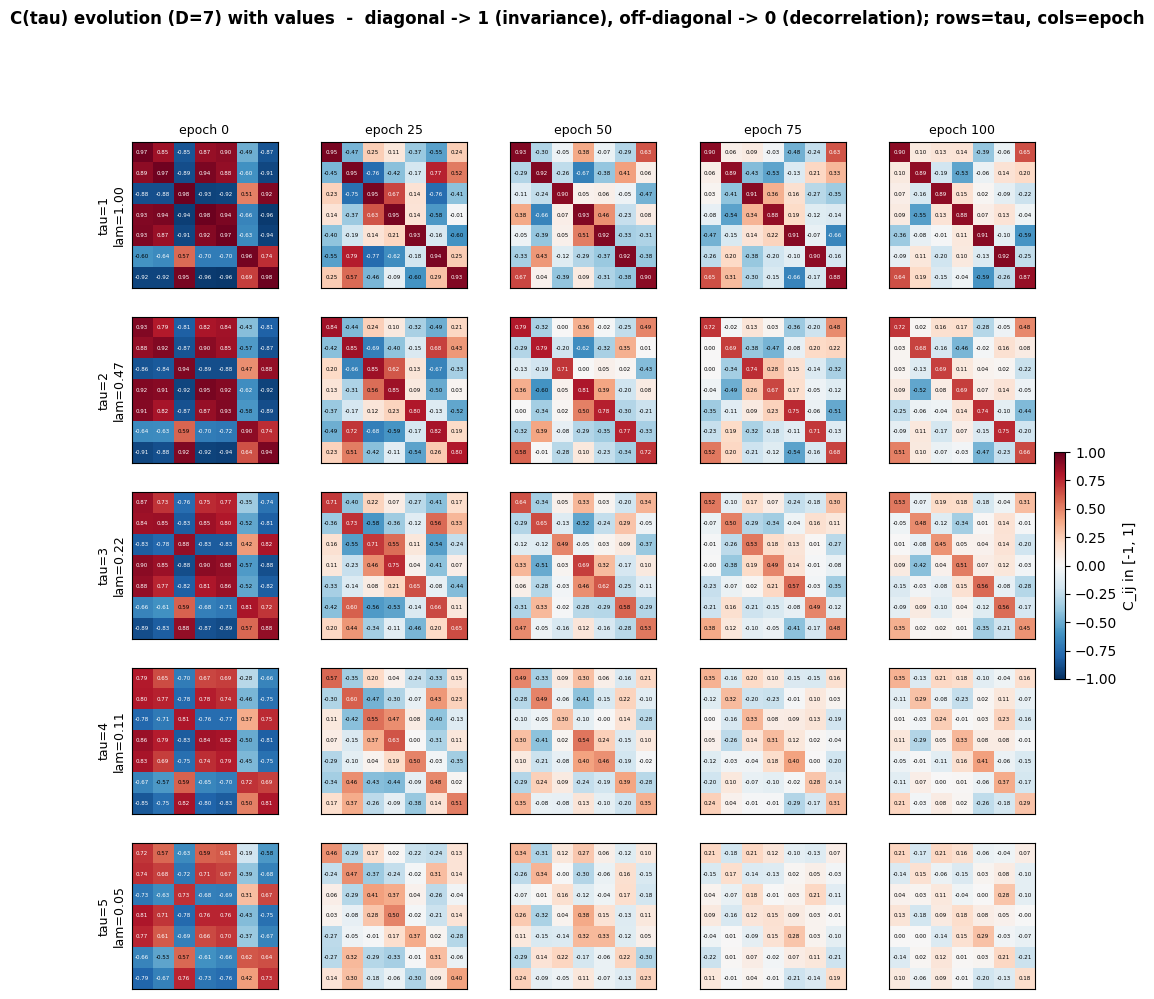

Saved /content/drive/MyDrive/BSISO_SSL_Project/MJO/barlow/D7/bt_corr_evolution.png
Saved interactive HTML -> /content/drive/MyDrive/BSISO_SSL_Project/MJO/barlow/D7/bt_corr_evolution_interactive.html


In [7]:
# C(tau) cross-correlation evolution over training (static grid + interactive slider, WITH values).
# Loads bt_corr_history.npz written by nb26 Cell 5 (per-epoch C). No retraining needed.
import os, glob, numpy as np, matplotlib.pyplot as plt
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
except ImportError:
    import subprocess, sys; subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'plotly'])
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive; drive.mount('/content/drive')
MJO_DIR = '/content/drive/MyDrive/BSISO_SSL_Project/MJO'
hits = sorted(glob.glob(f'{MJO_DIR}/barlow/**/bt_corr_history.npz', recursive=True))
pref = [f'{MJO_DIR}/barlow/D7/bt_corr_history.npz', f'{MJO_DIR}/barlow/bt_corr_history.npz']
npz = next((p for p in pref if p in hits), (hits[0] if hits else None))
if npz is None:
    print('bt_corr_history.npz NOT found. Current contents of', f'{MJO_DIR}/barlow:')
    for root, _, files in os.walk(f'{MJO_DIR}/barlow'):
        for f in sorted(files): print('   ', os.path.join(root, f))
    raise AssertionError('No bt_corr_history.npz. Run nb26 Cell 5 from the UPDATED notebook once '
                         '(it prints "Recorded C(tau) ... -> bt_corr_history.npz").')
d = np.load(npz); taus = d['taus'].tolist(); lams = d['lambdas'].tolist(); outdir = os.path.dirname(npz)
Chist = {t: d[f'C_tau{t}'] for t in taus}
E = Chist[taus[0]].shape[0]; D = Chist[taus[0]].shape[1]
print(f'Loaded {npz}  ({E} epoch snapshots, D={D})')

# --- static grid WITH exact values ---
sel = sorted(set([0, max(1, E // 4), E // 2, 3 * E // 4, E - 1]))
fs = 9 if D <= 3 else (6 if D <= 5 else 4)
fig, axes = plt.subplots(len(taus), len(sel), figsize=(2.2 * len(sel) + 1.2, 2.2 * len(taus)), squeeze=False)
im = None
for r, t in enumerate(taus):
    for c, e in enumerate(sel):
        ax = axes[r][c]; Cm = Chist[t][e]; im = ax.imshow(Cm, vmin=-1, vmax=1, cmap='RdBu_r')
        for ii in range(D):
            for jj in range(D):
                ax.text(jj, ii, f'{Cm[ii, jj]:.2f}', ha='center', va='center', fontsize=fs,
                        color='white' if abs(Cm[ii, jj]) > 0.6 else 'black')
        ax.set_xticks([]); ax.set_yticks([])
        if r == 0: ax.set_title(f'epoch {e}', fontsize=9)
        if c == 0: ax.set_ylabel(f'tau={t}\nlam={lams[r]:.2f}', fontsize=9)
fig.suptitle(f'C(tau) evolution (D={D}) with values  -  diagonal -> 1 (invariance), off-diagonal -> 0 (decorrelation); rows=tau, cols=epoch',
             fontweight='bold', y=1.0)
fig.colorbar(im, ax=axes, fraction=0.012, pad=0.02, label='C_ij in [-1, 1]')
ps = f'{outdir}/bt_corr_evolution.png'; plt.savefig(ps, dpi=150, bbox_inches='tight'); plt.show(); print('Saved', ps)

# --- interactive slider WITH live values ---
tf = 12 if D <= 3 else (9 if D <= 5 else 7)
def heat(z, show):
    return go.Heatmap(z=z, zmin=-1, zmax=1, colorscale='RdBu', reversescale=True, showscale=show,
                      texttemplate='%{z:.2f}', textfont=dict(size=tf))
fig = make_subplots(1, len(taus), horizontal_spacing=0.04,
                    subplot_titles=[f'tau={t} (lam={lams[i]:.2f})' for i, t in enumerate(taus)])
for i, t in enumerate(taus):
    fig.add_trace(heat(Chist[t][0], i == len(taus) - 1), row=1, col=i + 1)
fig.frames = [go.Frame(name=str(e), data=[heat(Chist[t][e], i == len(taus) - 1) for i, t in enumerate(taus)])
              for e in range(E)]
steps = [dict(method='animate', label=str(e),
             args=[[str(e)], dict(mode='immediate', frame=dict(duration=0, redraw=True), transition=dict(duration=0))])
         for e in range(E)]
fig.update_layout(height=380, width=330 * len(taus),
    title='Interactive C(tau) evolution with live values - drag the epoch slider (diagonal -> 1, off -> 0)',
    sliders=[dict(active=0, currentvalue=dict(prefix='epoch '), steps=steps)],
    updatemenus=[dict(type='buttons', x=0, y=1.3,
                 buttons=[dict(label='play', method='animate',
                          args=[None, dict(frame=dict(duration=200, redraw=True), fromcurrent=True)])])])
fig.update_yaxes(autorange='reversed')
ph = f'{outdir}/bt_corr_evolution_interactive.html'; fig.write_html(ph); print('Saved interactive HTML ->', ph); fig.show()

---
## Done!

Two figures in `MJO/barlow/`: `D7_embedding_2d.png` (PCA+t-SNE scatter) and `D7_trajectories_pca.png` (event paths).

No retraining was needed — this reuses the saved D=7 `embeddings_z7.npy`. If you ever want the *exact* numbers/figures regenerated from the model, re-run nb26 with `PROJ_DIM=7` instead.

---
*DDCS Project | jh9141@nyu.edu*